# Klasifikasi Multi-Kelas Citra Histopatologi Kanker Payudara
## EdgeNeXt-XXS pada Dataset BreaKHis (8 Subtipe, Magnifikasi 40X)

---

### Daftar Isi

1. [Setup & Import Library](#1.-Setup-&-Import-Library)
2. [Konfigurasi Proyek & Loading Dataset](#2.-Konfigurasi-Proyek-&-Loading-Dataset)
3. [Data Augmentasi & Generator](#3.-Data-Augmentasi-&-Generator)
4. [Class Weighting (Penanganan Data Imbalance)](#4.-Class-Weighting-(Penanganan-Data-Imbalance))
5. [Arsitektur Model — EdgeNeXt-XXS](#5.-Arsitektur-Model-%E2%80%94-EdgeNeXt-XXS)
6. [Setup Callbacks (Training)](#6.-Setup-Callbacks-(Training))
7. [Grafik Akurasi & Loss](#7.-Grafik-Akurasi-&-Loss)
8. [Evaluasi — Classification Report & Confusion Matrix](#8.-Evaluasi-%E2%80%94-Classification-Report-&-Confusion-Matrix)
9. [Evaluasi Lanjutan — ROC Curve & Precision-Recall Curve](#9.-Evaluasi-Lanjutan-%E2%80%94-ROC-Curve-&-Precision-Recall-Curve)
10. [Explainable AI — Grad-CAM](#10.-Explainable-AI-%E2%80%94-Grad-CAM)
11. [Download Semua Laporan Evaluasi](#11.-Download-Semua-Laporan-Evaluasi)

---


## 1. Setup & Import Library

Inisialisasi seluruh dependensi, konfigurasi perangkat komputasi (CPU/GPU), dan gaya visual global yang digunakan sepanjang notebook.

In [1]:
# ==============================================================================
# 1. SETUP & IMPORT LIBRARY
# ==============================================================================
# Instalasi dan inisialisasi seluruh dependensi yang digunakan sepanjang
# notebook: manipulasi data (NumPy, Pandas), pemrosesan citra (OpenCV),
# pembelajaran mesin (scikit-learn), deep learning (PyTorch/torchvision/timm),
# serta visualisasi (Matplotlib, Seaborn).
!pip install torch torchvision timm opencv-python scikit-learn matplotlib seaborn -q

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
import timm  # Menyediakan arsitektur EdgeNeXt-XXS pra-latih ImageNet

import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------------------
# Konfigurasi perangkat komputasi (GPU diprioritaskan apabila tersedia)
# ------------------------------------------------------------------------
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ------------------------------------------------------------------------
# Konfigurasi gaya visual global (Matplotlib & Seaborn)
# Diterapkan sekali di awal notebook agar seluruh grafik evaluasi --
# kurva pelatihan, confusion matrix, ROC/PR curve, hingga Grad-CAM --
# memiliki tampilan yang konsisten dan sesuai standar publikasi ilmiah.
# ------------------------------------------------------------------------
ACCENT_BLUE   = '#1f77b4'
ACCENT_ORANGE = '#ff7f0e'
TEXT_DARK     = '#2b2b2b'

sns.set_theme(style='whitegrid', font_scale=1.0)
mpl.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'axes.edgecolor'    : '#4a4a4a',
    'axes.labelcolor'   : TEXT_DARK,
    'axes.titleweight'  : 'bold',
    'axes.titlesize'    : 14,
    'axes.titlepad'     : 12,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'text.color'        : TEXT_DARK,
    'xtick.color'       : TEXT_DARK,
    'ytick.color'       : TEXT_DARK,
    'font.family'       : 'DejaVu Sans',
    'savefig.facecolor' : 'white',
    'savefig.dpi'       : 200,
})

print(f'PyTorch version   : {torch.__version__}')
print(f'timm version      : {timm.__version__}')
print(f'GPU tersedia      : {torch.cuda.is_available()}')
print(f'Perangkat digunakan: {DEVICE}')


PyTorch version   : 2.10.0+cu128
timm version      : 1.0.26
GPU tersedia      : True
Perangkat digunakan: cuda


In [2]:
# ==============================================================================
# DIREKTORI PENYIMPANAN LAPORAN EVALUASI
# ==============================================================================
# Seluruh artefak evaluasi (grafik pelatihan, classification report,
# confusion matrix, kurva ROC/PR, dan visualisasi Grad-CAM) disimpan secara
# terpusat pada direktori berikut, sehingga dapat diunduh sekaligus sebagai
# satu berkas arsip pada bagian akhir notebook (lihat Bagian 11).
REPORT_DIR = '/kaggle/working/laporan_evaluasi'
os.makedirs(REPORT_DIR, exist_ok=True)
print(f'Direktori laporan evaluasi siap digunakan: {REPORT_DIR}')


Direktori laporan evaluasi siap digunakan: /kaggle/working/laporan_evaluasi


## 2. Konfigurasi Proyek & Loading Dataset

Definisi parameter eksperimen (magnifikasi, ukuran citra, batch size, daftar kelas) serta pemuatan dan penyaringan dataset BreaKHis berdasarkan tingkat magnifikasi target.

In [3]:
# ==============================================================================
# 2.1 KONFIGURASI PROYEK (SINGLE SOURCE OF TRUTH)
# ==============================================================================
# Seluruh parameter eksperimen didefinisikan secara terpusat pada sel ini.
# Sel-sel berikutnya dalam notebook mengacu pada nilai TARGET_MAGNIFICATION
# yang ditetapkan di sini, sehingga perubahan tingkat magnifikasi cukup
# dilakukan satu kali tanpa perlu menyunting sel-sel lain secara manual.
DATASET_PATH         = '/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast'

TARGET_MAGNIFICATION = '200X'  # Opsi: '40X', '100X', '200X', atau '400X'
IMG_SIZE             = 224
BATCH_SIZE           = 32
SEED                 = 42

# Delapan subtipe histopatologi didefinisikan secara eksplisit agar urutan
# indeks kelas konsisten pada seluruh proses pelatihan dan evaluasi.
CLASS_NAMES = [
    'adenosis', 'fibroadenoma', 'phyllodes_tumor', 'tubular_adenoma',
    'ductal_carcinoma', 'lobular_carcinoma', 'mucinous_carcinoma', 'papillary_carcinoma'
]

# ==============================================================================
# 2.2 PEMUATAN DAN PENYARINGAN DATASET BERDASARKAN MAGNIFIKASI
# ==============================================================================
import pandas as pd
from pathlib import Path

def load_and_filter_dataset(base_path: str, target_mag: str) -> pd.DataFrame:
    '''Membaca struktur direktori dataset BreaKHis dan menyaring citra
    berdasarkan tingkat magnifikasi yang ditentukan.

    Parameters
    ----------
    base_path : str
        Path direktori akar dataset BreaKHis.
    target_mag : str
        Tingkat magnifikasi target penyaringan (mis. '40X').

    Returns
    -------
    pd.DataFrame
        DataFrame berisi kolom 'filepath' dan 'label' untuk seluruh citra
        yang sesuai dengan magnifikasi target.
    '''
    records = []

    for img_path in Path(base_path).rglob('*.png'):
        parts = img_path.parts
        magnification = parts[-2]

        if magnification == target_mag:
            subtype = parts[-4].lower()
            records.append({
                'filepath' : str(img_path),
                'label'    : subtype
            })

    return pd.DataFrame(records)

print(f'Mencari data untuk magnifikasi {TARGET_MAGNIFICATION}...')
df_target = load_and_filter_dataset(DATASET_PATH, TARGET_MAGNIFICATION)

print(f'Total citra dengan magnifikasi {TARGET_MAGNIFICATION} yang ditemukan: {len(df_target)}')
print('\nDistribusi kelas:')
print(df_target['label'].value_counts())


Mencari data untuk magnifikasi 200X...
Total citra dengan magnifikasi 200X yang ditemukan: 2013

Distribusi kelas:
label
ductal_carcinoma       896
fibroadenoma           264
mucinous_carcinoma     196
lobular_carcinoma      163
tubular_adenoma        140
papillary_carcinoma    135
adenosis               111
phyllodes_tumor        108
Name: count, dtype: int64


## 3. Data Augmentasi & Generator

Pembagian dataset secara stratified image-level (70/15/15), definisi pipeline augmentasi geometris untuk data latih, serta pembentukan `Dataset` dan `DataLoader` PyTorch.

Alokasi data (200X) -> Latih: 1409 | Validasi: 302 | Uji: 302


Menampilkan contoh hasil augmentasi pada satu citra mentah (magnifikasi 200X)


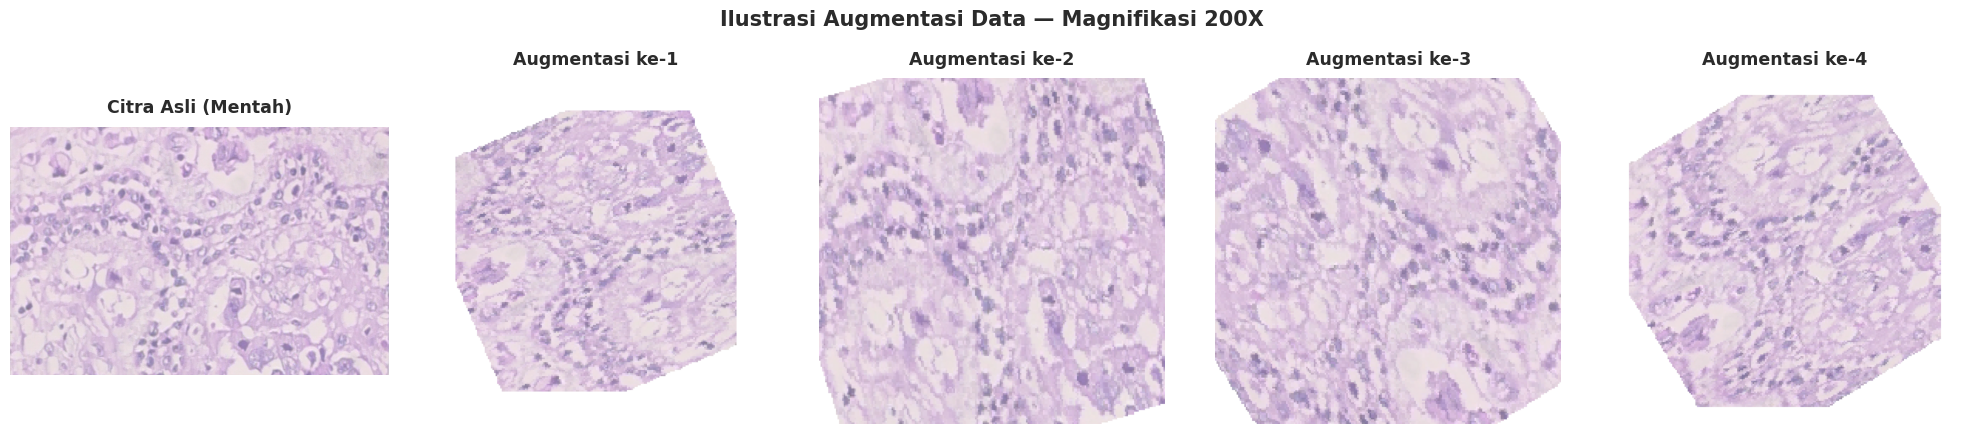

In [4]:
# ==============================================================================
# 3. AUGMENTASI DATA DAN PEMBENTUKAN GENERATOR (DATA MENTAH)
# ==============================================================================
# Sel ini menggunakan variabel konfigurasi (DATASET_PATH, TARGET_MAGNIFICATION,
# CLASS_NAMES, IMG_SIZE, BATCH_SIZE, SEED) yang telah didefinisikan pada
# Bagian 2. Dengan demikian, perubahan tingkat magnifikasi maupun parameter
# lain cukup dilakukan satu kali pada sel konfigurasi, dan seluruh proses
# di sel ini beserta keterangan pada visualisasi akan menyesuaikan secara
# otomatis tanpa perlu penyuntingan ulang.
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# ------------------------------------------------------------------------
# 3.1 Pembagian Dataset (70% Latih, 15% Validasi, 15% Uji)
# ------------------------------------------------------------------------
# `df_target` menggunakan hasil pemuatan dataset yang telah dilakukan pada
# Bagian 2.2, sehingga proses pemindaian direktori dataset tidak perlu
# diulang di sel ini.
# Pembagian dilakukan secara stratified pada tingkat citra (image-level)
# agar proporsi tiap kelas tetap terjaga pada seluruh subset data.
train_df, temp_df = train_test_split(
    df_target, test_size=0.3, stratify=df_target['label'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=SEED
)
print(f'Alokasi data ({TARGET_MAGNIFICATION}) -> Latih: {len(train_df)} | '
      f'Validasi: {len(val_df)} | Uji: {len(test_df)}\n')

# ------------------------------------------------------------------------
# 3.2 Konfigurasi Praproses DenseNet-121 (Normalisasi ImageNet Mean/Std)
# ------------------------------------------------------------------------
# Ekuivalen dengan tensorflow.keras.applications.densenet.preprocess_input
# dalam mode 'torch': nilai piksel diskalakan ke [0, 1], kemudian
# dinormalisasi menggunakan mean/std ImageNet per kanal.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class_to_idx = {name: idx for idx, name in enumerate(CLASS_NAMES)}

def _pil_loader_rgb(path):
    '''Membaca citra menggunakan OpenCV dan mengonversinya ke ruang warna
    RGB, agar konsisten dengan pipeline Grad-CAM pada bagian akhir notebook.
    '''
    img = cv2.imread(str(path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

class BreaKHisDataset(Dataset):
    '''Dataset PyTorch kustom untuk citra BreaKHis, ekuivalen dengan
    ImageDataGenerator.flow_from_dataframe pada versi Keras.

    Parameters
    ----------
    dataframe : pd.DataFrame
        DataFrame berisi kolom 'filepath' dan 'label'.
    class_to_idx : dict
        Pemetaan nama kelas ke indeks numerik.
    transform : callable, optional
        Transformasi (augmentasi/normalisasi) yang diterapkan pada citra.
    img_size : int
        Dimensi target citra setelah resize (persegi).
    '''

    def __init__(self, dataframe, class_to_idx, transform=None, img_size=224):
        self.df = dataframe.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.transform = transform
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = _pil_loader_rgb(row['filepath'])
        img = cv2.resize(img, (self.img_size, self.img_size))

        if self.transform:
            img = self.transform(img)

        label = self.class_to_idx[row['label']]
        return img, label

# Augmentasi hanya diterapkan pada data latih untuk meningkatkan variasi dan
# generalisasi model. Normalisasi ImageNet (mean/std) diterapkan sebagai
# bagian dari pipeline pelatihan, sehingga generator ini menghasilkan tensor
# yang siap digunakan langsung oleh model, bukan citra dalam rentang nilai
# piksel yang dapat divisualisasikan secara langsung.
#
# Catatan metodologis (warna padding augmentasi):
# Area kosong yang muncul akibat rotasi dan scaling diisi dengan warna putih
# (255, 255, 255), karena warna ini mendekati warna latar slide kaca
# histopatologi asli (putih/krem terang). Dengan demikian, area padding
# tetap netral dan realistis, serta tidak menimbulkan nilai piksel ekstrem
# setelah normalisasi ImageNet yang berpotensi diserap model sebagai sinyal
# palsu.
FILL_COLOR = (255, 255, 255)  # putih -- mendekati warna latar slide histopatologi asli

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(degrees=360, fill=FILL_COLOR),  # Rotasi bebas 360 derajat (rotation-invariant)
    transforms.RandomHorizontalFlip(p=0.5),                    # Pembalikan horizontal
    transforms.RandomVerticalFlip(p=0.5),                      # Pembalikan vertikal
    transforms.RandomAffine(degrees=0, scale=(0.8, 1.2), fill=FILL_COLOR),  # Variasi zoom 20%
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),  # Normalisasi resmi DenseNet-121
])

# Data validasi dan uji tidak diberi augmentasi geometris; hanya menerapkan
# praproses yang identik dengan jalur inferensi model, agar evaluasi tetap
# merepresentasikan kondisi data yang sesungguhnya.
val_test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ------------------------------------------------------------------------
# 3.3 Pembentukan Dataset & DataLoader
# ------------------------------------------------------------------------
train_dataset = BreaKHisDataset(train_df, class_to_idx, transform=train_transform, img_size=IMG_SIZE)
val_dataset   = BreaKHisDataset(val_df,   class_to_idx, transform=val_test_transform, img_size=IMG_SIZE)
test_dataset  = BreaKHisDataset(test_df,  class_to_idx, transform=val_test_transform, img_size=IMG_SIZE)

train_gen = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_gen   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_gen  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Pemetaan nama kelas -> indeks numerik disimpan sebagai variabel independen
# (bukan atribut tambahan pada objek DataLoader), digunakan pada bagian
# evaluasi (Bagian 8 & 9) untuk menyusun urutan nama kelas yang konsisten.
class_indices = class_to_idx

# ==============================================================================
# 3.4 VISUALISASI CONTOH HASIL AUGMENTASI
# ==============================================================================
# Catatan metodologis:
# Transformasi augmentasi untuk visualisasi (preview_transform) sengaja dibuat
# TANPA normalisasi ImageNet (Normalize). Normalisasi ImageNet mengonversi
# nilai piksel ke rentang yang mengandung nilai negatif dan nilai di atas 1
# (mean/std scaling), sehingga jika citra hasil normalisasi tersebut langsung
# ditampilkan dengan imshow(), Matplotlib akan memotong (clipping) nilai-nilai
# tersebut ke rentang [0, 1] dan menghasilkan citra yang tampak rusak atau
# berwarna tidak wajar. Transformasi ini digunakan murni untuk keperluan
# ilustrasi visual dan tidak memengaruhi data yang digunakan pada proses
# pelatihan model.
print(f'\nMenampilkan contoh hasil augmentasi pada satu citra mentah '
      f'(magnifikasi {TARGET_MAGNIFICATION})')

preview_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(degrees=360, fill=FILL_COLOR),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomAffine(degrees=0, scale=(0.8, 1.2), fill=FILL_COLOR),
    transforms.ToTensor(),  # Skala [0, 1] khusus untuk keperluan visualisasi
])

sample_df = train_df.sample(1, random_state=SEED)  # Pengambilan satu citra secara acak
sample_img_raw = _pil_loader_rgb(sample_df['filepath'].values[0])
sample_img_raw = cv2.resize(sample_img_raw, (IMG_SIZE, IMG_SIZE))

fig, axes = plt.subplots(1, 5, figsize=(20, 4.2))
fig.patch.set_facecolor('white')

axes[0].imshow(plt.imread(sample_df['filepath'].values[0]))
axes[0].set_title('Citra Asli (Mentah)', fontsize=12.5, fontweight='bold', color=TEXT_DARK, pad=10)
axes[0].axis('off')

# Menampilkan empat variasi hasil augmentasi
for i in range(1, 5):
    aug_tensor = preview_transform(sample_img_raw)
    aug_img = aug_tensor.permute(1, 2, 0).numpy()  # CHW -> HWC untuk imshow
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Augmentasi ke-{i}', fontsize=12.5, fontweight='bold', color=TEXT_DARK, pad=10)
    axes[i].axis('off')

fig.suptitle(f'Ilustrasi Augmentasi Data — Magnifikasi {TARGET_MAGNIFICATION}',
             fontsize=15, fontweight='bold', color=TEXT_DARK, y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, f'00_ilustrasi_augmentasi_{TARGET_MAGNIFICATION}.png'),
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


## 4. Class Weighting (Penanganan Data Imbalance)

Perhitungan bobot kelas berbasis skema *balanced* untuk mengurangi bias model terhadap kelas mayoritas pada fungsi loss.

In [5]:
# ==============================================================================
# 4. PERHITUNGAN CLASS WEIGHTING (PENANGANAN DATA IMBALANCE)
# ==============================================================================
# Dataset BreaKHis memiliki distribusi kelas yang tidak seimbang antar
# subtipe histopatologi. Class weighting diterapkan pada fungsi loss agar
# kelas dengan jumlah sampel lebih sedikit memperoleh bobot kontribusi
# lebih besar terhadap gradien, sehingga mengurangi bias model terhadap
# kelas mayoritas.
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

print('Menghitung class weighting untuk data latih...')

# 1. Mengambil seluruh label target dari DataFrame data latih
train_labels = train_df['label'].values

# 2. Menghitung bobot proporsional (skema 'balanced') menggunakan scikit-learn:
#    kelas dengan jumlah sampel sedikit memperoleh bobot lebih besar, dan
#    sebaliknya, mengikuti n_samples / (n_classes * n_samples_kelas).
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# 3. Mengonversi hasil ke dalam format dictionary untuk keterbacaan laporan
class_weight_dict = {}

# Pemetaan indeks numerik dari class_to_idx (mis: {'adenosis': 0, ...})
class_indices = class_to_idx

for class_name, weight in zip(np.unique(train_labels), class_weights_array):
    class_index = class_indices[class_name]
    class_weight_dict[class_index] = weight

# Menampilkan bobot kelas untuk didokumentasikan pada laporan skripsi
print('\nBobot kelas (class weights) yang digunakan:')
for class_name, idx in class_indices.items():
    print(f'  - {class_name:<20s} (index {idx}): {class_weight_dict[idx]:.4f}')

# 4. Menyusun tensor bobot kelas terurut berdasarkan indeks (0..n_classes-1),
#    format yang dibutuhkan oleh nn.CrossEntropyLoss(weight=...) pada PyTorch --
#    ekuivalen dengan argumen class_weight pada model.fit() versi Keras.
class_weights_tensor = torch.tensor(
    [class_weight_dict[i] for i in range(len(CLASS_NAMES))],
    dtype=torch.float32
).to(DEVICE)

print('\nTensor bobot kelas siap disisipkan ke dalam fungsi loss (CrossEntropyLoss).')


Menghitung class weighting untuk data latih...

Bobot kelas (class weights) yang digunakan:
  - adenosis             (index 0): 2.2580
  - fibroadenoma         (index 1): 0.9520
  - phyllodes_tumor      (index 2): 2.3174
  - tubular_adenoma      (index 3): 1.7972
  - ductal_carcinoma     (index 4): 0.2809
  - lobular_carcinoma    (index 5): 1.5450
  - mucinous_carcinoma   (index 6): 1.2856
  - papillary_carcinoma  (index 7): 1.8737

Tensor bobot kelas siap disisipkan ke dalam fungsi loss (CrossEntropyLoss).


## 5. Arsitektur Model — EdgeNeXt-XXS

Definisi arsitektur EdgeNeXt-XXS (hybrid CNN-Transformer ringan, arsitektur `timm`) dengan skema *partial fine-tuning*, kepala klasifikasi kustom, fungsi loss berbobot, dan optimizer.


In [6]:
# ==============================================================================
# 5. ARSITEKTUR MODEL — EDGENEXT-XXS (8 KELAS)
# ==============================================================================
# Model dibangun di atas EdgeNeXt-XXS pra-latih ImageNet (via timm), sebuah
# arsitektur hybrid CNN-Transformer ringan (~1.3M parameter backbone) yang
# dirancang untuk perangkat edge. Skema transfer learning parsial (partial
# fine-tuning) diterapkan: sebagian besar bobot ekstraksi fitur dibekukan,
# sementara stage konvolusi terakhir dibuka agar dapat mempelajari fitur
# morfologis spesifik pada citra histopatologi kanker payudara. Kepala
# klasifikasi (classification head) dipertahankan IDENTIK dengan seluruh
# notebook perbandingan arsitektur lain dalam penelitian ini, guna menjaga
# desain apple-to-apple.
import torch.nn as nn
import timm

class EdgeNeXtXXSClassifier(nn.Module):
    '''Model EdgeNeXt-XXS untuk klasifikasi 8 subtipe histopatologi.

    Arsitektur kepala klasifikasi (classification head) identik dengan
    seluruh notebook perbandingan pada penelitian ini:
    EdgeNeXt-XXS (ImageNet, backbone) -> GlobalAveragePooling2D
    -> Dense(256, relu) -> Dropout(0.4) -> Dense(n_classes, softmax).

    Skema Fine-Tuning
    ------------------
    Backbone dimuat melalui `timm.create_model(..., num_classes=0,
    global_pool='')` sehingga head klasifikasi bawaan timm (NormMlpClassifierHead)
    tidak turut serta -- hanya feature extractor (`stem` + `stages`) yang
    dipertahankan. Seluruh parameter backbone dibekukan terlebih dahulu,
    kemudian sejumlah tensor parameter terakhir (mencakup blok konvolusi
    `stages[-1]` bagian akhir) dibuka kembali untuk pelatihan (fine-tuning),
    dengan JUMLAH TENSOR YANG DIBUKA (30) identik dengan skema baseline
    DenseNet-121, sehingga proporsi fine-tuning tetap sebanding pada
    perbandingan antar-arsitektur.

    Parameters
    ----------
    n_classes : int
        Jumlah kelas keluaran (default: 8, sesuai subtipe BreaKHis).
    '''

    def __init__(self, n_classes: int = 8):
        super().__init__()

        # Memuat backbone EdgeNeXt-XXS pra-latih ImageNet, tanpa head
        # klasifikasi bawaan (num_classes=0) dan tanpa pooling internal
        # (global_pool='') -- feature map spasial (B, 168, 7, 7) dipertahankan
        # agar pooling & Grad-CAM dapat dikendalikan secara eksplisit,
        # setara dengan `base.features` pada versi DenseNet-121.
        self.backbone = timm.create_model(
            'edgenext_xx_small', pretrained=True, num_classes=0, global_pool=''
        )
        self.feature_dim = self.backbone.num_features  # 168 untuk EdgeNeXt-XXS

        # 1. Membekukan (freeze) seluruh parameter backbone
        for param in self.backbone.parameters():
            param.requires_grad = False

        # 2. Membuka kembali (unfreeze) 30 tensor parameter terakhir untuk
        #    fine-tuning -- jumlah identik dengan skema baseline DenseNet-121,
        #    mencakup blok konvolusi & attention pada `stages[-1]` (stage
        #    resolusi terendah, fitur paling abstrak/spesifik-domain).
        params_list = list(self.backbone.parameters())
        for param in params_list[-30:]:
            param.requires_grad = True

        # 3. Kepala klasifikasi (classification head) di atas backbone --
        #    IDENTIK dengan arsitektur head pada seluruh notebook perbandingan.
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))  # GlobalAveragePooling2D
        self.fc1 = nn.Linear(self.feature_dim, 256)      # Dense(256, activation='relu')
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.4)                   # Dropout(0.4) -- mencegah overfitting

        # Lapisan keluaran 8 neuron; aktivasi softmax diterapkan implisit
        # melalui nn.CrossEntropyLoss (kombinasi LogSoftmax + NLLLoss)
        self.fc2 = nn.Linear(256, n_classes)

    def forward(self, x):
        x = self.backbone.forward_features(x)  # (B, 168, H, W) -- feature map spasial
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x  # Logit mentah; softmax diterapkan saat probabilitas dibutuhkan (evaluasi)


def build_8class_edgenext_model(n_classes: int = 8) -> nn.Module:
    '''Membangun dan memindahkan model EdgeNeXt-XXS (8 kelas) ke perangkat
    komputasi aktif (`DEVICE`).
    '''
    model = EdgeNeXtXXSClassifier(n_classes=n_classes)
    return model.to(DEVICE)

# Inisialisasi model tunggal untuk klasifikasi 8 kelas
model = build_8class_edgenext_model(n_classes=8)

# CrossEntropyLoss (menggabungkan Softmax + NLLLoss) digunakan karena label
# berupa indeks kelas (bukan one-hot), dengan bobot kelas (class_weight)
# sesuai hasil perhitungan pada Bagian 4.
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Optimizer AdamW (lr=1e-4, weight_decay=1e-2), mengikuti protokol eksperimen
# standar yang diterapkan pada seluruh notebook perbandingan arsitektur
# dalam penelitian ini, guna menjaga konsistensi perbandingan antar-model.
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

print('Arsitektur model 8 kelas berhasil disusun.\n')
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal parameter          : {total_params:,}')
print(f'Parameter dapat dilatih  : {trainable_params:,}')
print(f'Parameter dibekukan      : {total_params - trainable_params:,}')


model.safetensors:   0%|          | 0.00/5.32M [00:00<?, ?B/s]

Arsitektur model 8 kelas berhasil disusun.

EdgeNeXtXXSClassifier(
  (backbone): EdgeNeXt(
    (stem): Sequential(
      (0): Conv2d(3, 24, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((24,), eps=1e-06, elementwise_affine=True)
    )
    (stages): Sequential(
      (0): EdgeNeXtStage(
        (downsample): Identity()
        (blocks): Sequential(
          (0): ConvBlock(
            (conv_dw): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=24)
            (norm): LayerNorm((24,), eps=1e-06, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): Linear(in_features=24, out_features=96, bias=True)
              (act): GELU(approximate='none')
              (drop1): Dropout(p=0.0, inplace=False)
              (norm): Identity()
              (fc2): Linear(in_features=96, out_features=24, bias=True)
              (drop2): Dropout(p=0.0, inplace=False)
            )
            (drop_path): Identity()
          )
          (1): ConvBlock

## 6. Setup Callbacks (Training)

Implementasi manual mekanisme *Early Stopping*, *Model Checkpoint*, dan *ReduceLROnPlateau*, serta eksekusi training loop utama.

In [7]:
# ==============================================================================
# 6. CALLBACKS (EARLY STOPPING, MODEL CHECKPOINT, LR SCHEDULER) & TRAINING LOOP
# ==============================================================================
# PyTorch tidak menyediakan mekanisme callback bawaan seperti Keras, sehingga
# EarlyStopping, ModelCheckpoint, dan ReduceLROnPlateau diimplementasikan
# secara manual di dalam training loop, dengan LOGIKA IDENTIK terhadap versi
# Keras: metrik yang dipantau, nilai patience, dan aksi yang diambil.
import copy
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau

model_filename = f'best_model_edgenext_xxs_{TARGET_MAGNIFICATION}.pt'

# Learning Rate Scheduler: mengurangi learning rate ketika val_loss stagnan,
# ekuivalen ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7)
lr_scheduler = ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=4, min_lr=1e-7
)

# Early Stopping: menghentikan pelatihan apabila val_loss tidak membaik
# selama sejumlah epoch berturut-turut,
# ekuivalen EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
EARLY_STOPPING_PATIENCE = 10
best_val_loss = float('inf')
best_val_accuracy = -float('inf')
epochs_no_improve = 0
best_model_state = None  # Menyimpan bobot terbaik untuk restore_best_weights=True

MAX_EPOCHS = 100  # Batas atas epoch; penghentian aktual dikendalikan oleh early stopping

history = {
    'accuracy': [], 'val_accuracy': [],
    'loss': [], 'val_loss': []
}

print(f'Memulai pelatihan model EdgeNeXt-XXS ({TARGET_MAGNIFICATION})...\n')

for epoch in range(MAX_EPOCHS):
    # --------------------------------------------------------------------
    # Fase Training
    # --------------------------------------------------------------------
    model.train()
    running_loss = 0.0
    running_correct = 0
    total_train = 0

    for inputs, labels in train_gen:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        running_correct += torch.sum(preds == labels).item()
        total_train += inputs.size(0)

    train_loss = running_loss / total_train
    train_acc = running_correct / total_train

    # --------------------------------------------------------------------
    # Fase Validasi
    # --------------------------------------------------------------------
    model.eval()
    val_running_loss = 0.0
    val_running_correct = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_gen:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_running_correct += torch.sum(preds == labels).item()
            total_val += inputs.size(0)

    val_loss = val_running_loss / total_val
    val_acc = val_running_correct / total_val

    history['accuracy'].append(train_acc)
    history['val_accuracy'].append(val_acc)
    history['loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    print(f'Epoch {epoch+1:3d}/{MAX_EPOCHS} - '
          f'loss: {train_loss:.4f} - accuracy: {train_acc:.4f} - '
          f'val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}')

    # Mencatat val_accuracy terbaik untuk keperluan pelaporan (bukan kriteria
    # penyimpanan model -- lihat catatan di bawah)
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc

    # Memperbarui learning rate scheduler berdasarkan val_loss
    lr_scheduler.step(val_loss)

    # Logika Early Stopping & Model Checkpoint, keduanya berdasarkan kriteria
    # val_loss yang identik (dengan restore_best_weights=True). Penyatuan
    # kriteria ini memastikan berkas .pt yang tersimpan = model yang
    # dievaluasi = model yang dipulihkan saat early stopping terpicu.
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), model_filename)
        print(f'  -> val_loss membaik ke {val_loss:.4f}; model disimpan ke \'{model_filename}\'')
    else:
        epochs_no_improve += 1
        print(f'  -> val_loss tidak membaik selama {epochs_no_improve} epoch (patience={EARLY_STOPPING_PATIENCE})')
        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print(f'\nEarly stopping terpicu pada epoch {epoch+1}. '
                  f'Memulihkan bobot terbaik (val_loss={best_val_loss:.4f})...')
            model.load_state_dict(best_model_state)
            break

# Memastikan bobot terbaik (berdasarkan val_loss) selalu dipulihkan di akhir
# pelatihan, ekuivalen dengan restore_best_weights=True pada EarlyStopping Keras.
if best_model_state is not None:
    model.load_state_dict(best_model_state)

print('\nPelatihan selesai.')


Memulai pelatihan model EdgeNeXt-XXS (200X)...

Epoch   1/100 - loss: 2.0684 - accuracy: 0.1994 - val_loss: 2.0272 - val_accuracy: 0.1921
  -> val_loss membaik ke 2.0272; model disimpan ke 'best_model_edgenext_xxs_200X.pt'
Epoch   2/100 - loss: 1.9285 - accuracy: 0.3307 - val_loss: 1.8475 - val_accuracy: 0.2947
  -> val_loss membaik ke 1.8475; model disimpan ke 'best_model_edgenext_xxs_200X.pt'
Epoch   3/100 - loss: 1.6703 - accuracy: 0.3513 - val_loss: 1.6162 - val_accuracy: 0.3874
  -> val_loss membaik ke 1.6162; model disimpan ke 'best_model_edgenext_xxs_200X.pt'
Epoch   4/100 - loss: 1.5170 - accuracy: 0.4088 - val_loss: 1.5043 - val_accuracy: 0.4404
  -> val_loss membaik ke 1.5043; model disimpan ke 'best_model_edgenext_xxs_200X.pt'
Epoch   5/100 - loss: 1.4054 - accuracy: 0.4223 - val_loss: 1.4626 - val_accuracy: 0.4338
  -> val_loss membaik ke 1.4626; model disimpan ke 'best_model_edgenext_xxs_200X.pt'
Epoch   6/100 - loss: 1.3005 - accuracy: 0.4698 - val_loss: 1.3979 - val_accu

## 7. Grafik Akurasi & Loss

Visualisasi dinamika metrik pelatihan dan validasi sepanjang epoch untuk mendiagnosis konvergensi, underfitting, maupun overfitting.

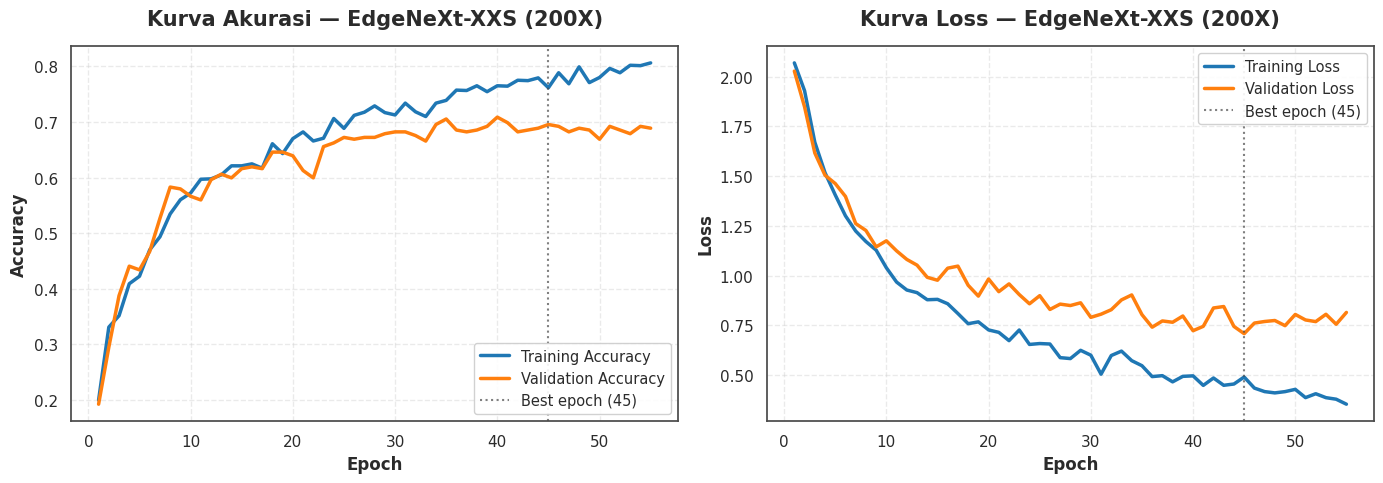

Model terbaik tercapai pada epoch 45 (val_loss = 0.7089, val_accuracy = 0.6954)


In [8]:
# ==============================================================================
# 7. VISUALISASI KURVA AKURASI & LOSS
# ==============================================================================
# Grafik ini menampilkan dinamika pelatihan (training) dan validasi
# (validation) sepanjang epoch, digunakan untuk mendiagnosis kondisi
# underfitting, overfitting, maupun konvergensi model. Ditempatkan setelah
# proses pelatihan (Bagian 6) selesai dieksekusi.
import matplotlib.pyplot as plt
import numpy as np

# Mengambil data metrik dari dictionary 'history' hasil pelatihan
acc = history['accuracy']
val_acc = history['val_accuracy']
loss = history['loss']
val_loss = history['val_loss']
epochs_range = range(1, len(acc) + 1)

# Menandai epoch dengan val_loss terbaik (checkpoint yang disimpan)
best_epoch = int(np.argmin(val_loss)) + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

# ------------------------------------------------------------------------
# 1. Kurva Akurasi
# ------------------------------------------------------------------------
ax1.plot(epochs_range, acc, label='Training Accuracy', color=ACCENT_BLUE, lw=2.5)
ax1.plot(epochs_range, val_acc, label='Validation Accuracy', color=ACCENT_ORANGE, lw=2.5)
ax1.axvline(best_epoch, color='#4a4a4a', linestyle=':', lw=1.5, alpha=0.7,
            label=f'Best epoch ({best_epoch})')

ax1.set_title(f'Kurva Akurasi — EdgeNeXt-XXS ({TARGET_MAGNIFICATION})', fontsize=15, pad=15)
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10.5, framealpha=0.9)
ax1.grid(True, linestyle='--', alpha=0.4)

# ------------------------------------------------------------------------
# 2. Kurva Loss
# ------------------------------------------------------------------------
ax2.plot(epochs_range, loss, label='Training Loss', color=ACCENT_BLUE, lw=2.5)
ax2.plot(epochs_range, val_loss, label='Validation Loss', color=ACCENT_ORANGE, lw=2.5)
ax2.axvline(best_epoch, color='#4a4a4a', linestyle=':', lw=1.5, alpha=0.7,
            label=f'Best epoch ({best_epoch})')

ax2.set_title(f'Kurva Loss — EdgeNeXt-XXS ({TARGET_MAGNIFICATION})', fontsize=15, pad=15)
ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10.5, framealpha=0.9)
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, f'01_grafik_akurasi_loss_{TARGET_MAGNIFICATION}.png'),
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print(f'Model terbaik tercapai pada epoch {best_epoch} '
      f'(val_loss = {val_loss[best_epoch-1]:.4f}, val_accuracy = {val_acc[best_epoch-1]:.4f})')


## 8. Evaluasi — Classification Report & Confusion Matrix

Evaluasi kuantitatif model pada data uji: precision, recall, F1-score per kelas, serta distribusi kesalahan klasifikasi antar kelas.

Memulai prediksi pada data uji (test set)...

                  CLASSIFICATION REPORT
                     precision    recall  f1-score   support

           adenosis       0.79      0.94      0.86        16
       fibroadenoma       0.78      0.72      0.75        40
    phyllodes_tumor       0.62      0.50      0.55        16
    tubular_adenoma       0.84      1.00      0.91        21
   ductal_carcinoma       0.85      0.67      0.75       134
  lobular_carcinoma       0.40      0.80      0.53        25
 mucinous_carcinoma       0.55      0.70      0.62        30
papillary_carcinoma       0.64      0.45      0.53        20

           accuracy                           0.71       302
          macro avg       0.68      0.72      0.69       302
       weighted avg       0.74      0.71      0.71       302


Menyusun confusion matrix...


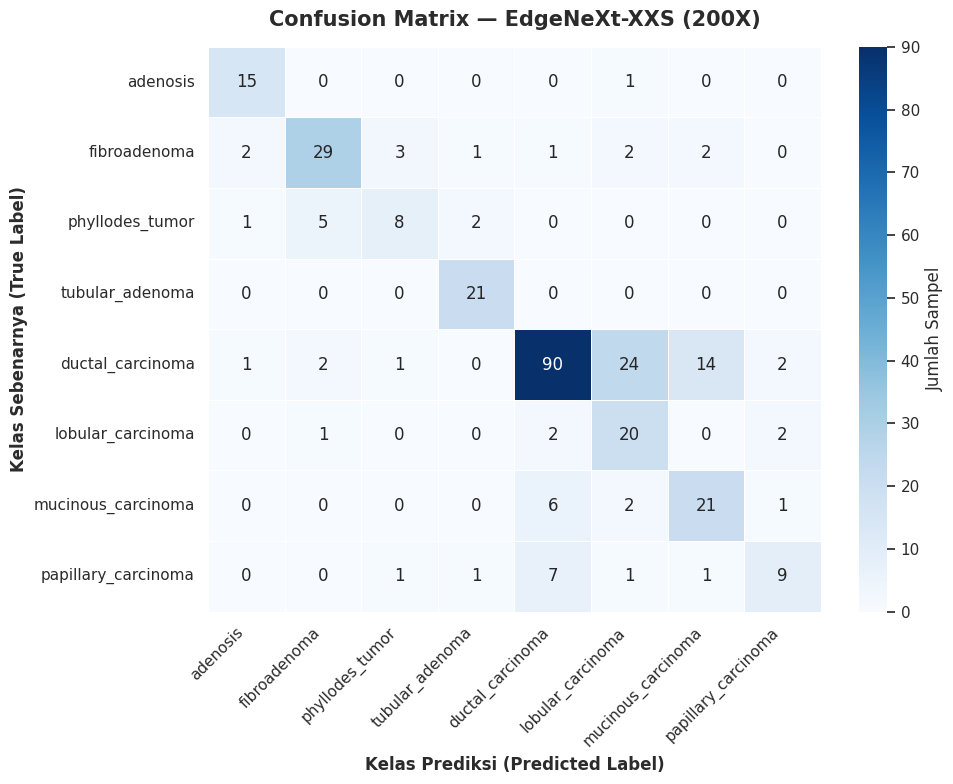

In [9]:
# ==============================================================================
# 8. EVALUASI — CLASSIFICATION REPORT & CONFUSION MATRIX
# ==============================================================================
# Evaluasi kuantitatif model pada data uji (test set), yang belum pernah
# dilihat oleh model selama proses pelatihan maupun validasi. Metrik yang
# dilaporkan meliputi precision, recall, F1-score per kelas (classification
# report) serta distribusi kesalahan klasifikasi antar kelas (confusion
# matrix).
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print('Memulai prediksi pada data uji (test set)...')

# 1. Mengatur model ke mode evaluasi (menonaktifkan dropout, membekukan
#    statistik batch normalization)
model.eval()

# 2. Melakukan prediksi terhadap seluruh data uji
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_gen:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)  # Konversi logit menjadi probabilitas
        preds = torch.argmax(probs, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

predictions = np.concatenate(all_probs, axis=0)

# 3. Kelas dengan probabilitas tertinggi (prediksi model)
y_pred = np.concatenate(all_preds, axis=0)

# 4. Label sebenarnya (ground truth)
y_true = np.concatenate(all_labels, axis=0)

# 5. Urutan nama kelas diambil dari pemetaan class_indices (didefinisikan
#    pada Bagian 3), memastikan urutan label pada grafik selalu konsisten
#    dengan indeks numerik model.
labels_dict_reversed = dict((v, k) for k, v in class_indices.items())
class_names_ordered = [labels_dict_reversed[k] for k in range(len(class_indices))]

# ------------------------------------------------------------------------
# A. Classification Report
# ------------------------------------------------------------------------
print('\n' + '=' * 60)
print(' ' * 18 + 'CLASSIFICATION REPORT')
print('=' * 60)
report_text = classification_report(y_true, y_pred, target_names=class_names_ordered)
print(report_text)

# Menyimpan classification report dalam format teks (.txt)
with open(os.path.join(REPORT_DIR, f'02_classification_report_{TARGET_MAGNIFICATION}.txt'), 'w') as f:
    f.write(f'CLASSIFICATION REPORT - EdgeNeXt-XXS ({TARGET_MAGNIFICATION})\n')
    f.write('=' * 60 + '\n')
    f.write(report_text)

# Menyimpan classification report dalam format tabular (.csv)
report_dict = classification_report(y_true, y_pred, target_names=class_names_ordered, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(os.path.join(REPORT_DIR, f'02_classification_report_{TARGET_MAGNIFICATION}.csv'))

# ------------------------------------------------------------------------
# B. Confusion Matrix
# ------------------------------------------------------------------------
print('\nMenyusun confusion matrix...')
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('white')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_ordered,
            yticklabels=class_names_ordered,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Jumlah Sampel'},
            ax=ax)

ax.set_title(f'Confusion Matrix — EdgeNeXt-XXS ({TARGET_MAGNIFICATION})', fontsize=15, pad=15)
ax.set_ylabel('Kelas Sebenarnya (True Label)', fontsize=12, fontweight='bold')
ax.set_xlabel('Kelas Prediksi (Predicted Label)', fontsize=12, fontweight='bold')

plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.setp(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, f'03_confusion_matrix_{TARGET_MAGNIFICATION}.png'),
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

# Menyimpan confusion matrix mentah dalam format tabular (.csv)
cm_df = pd.DataFrame(cm, index=class_names_ordered, columns=class_names_ordered)
cm_df.to_csv(os.path.join(REPORT_DIR, f'03_confusion_matrix_{TARGET_MAGNIFICATION}.csv'))


## 9. Evaluasi Lanjutan — ROC Curve & Precision-Recall Curve

Analisis performa model per kelas melalui pendekatan One-vs-Rest, mencakup ROC-AUC dan Average Precision.

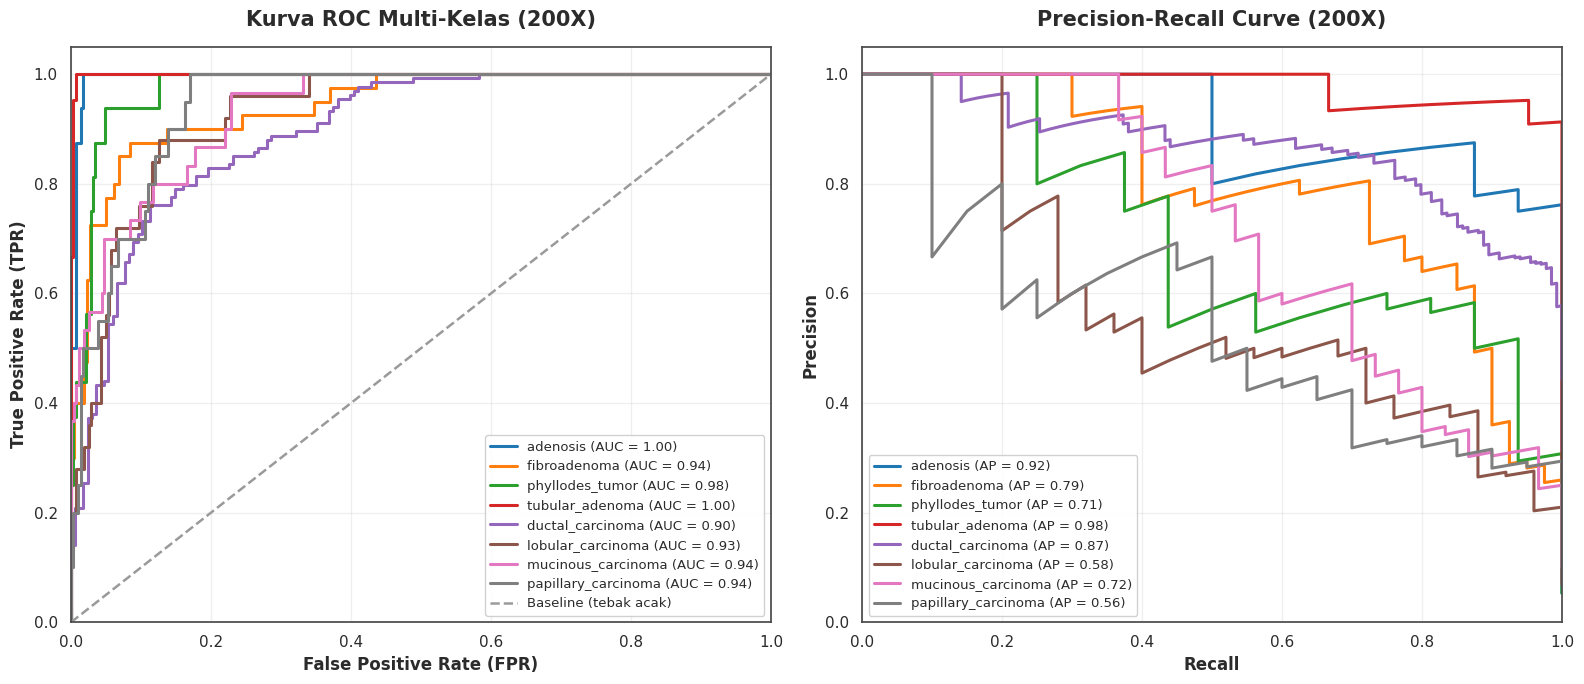

In [10]:
# ==============================================================================
# 9. EVALUASI LANJUTAN — ROC CURVE & PRECISION-RECALL CURVE (MULTI-KELAS)
# ==============================================================================
# Kurva ROC (Receiver Operating Characteristic) dan Precision-Recall (PR)
# dihitung menggunakan pendekatan One-vs-Rest (OvR) untuk setiap kelas.
# Kurva PR khususnya bermanfaat pada kondisi data tidak seimbang (class
# imbalance), karena lebih sensitif terhadap performa pada kelas minoritas
# dibandingkan kurva ROC.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Probabilitas prediksi (`predictions`) dan label sebenarnya (`y_true`) telah
# dihitung pada Bagian 8, sehingga forward pass terhadap test set tidak perlu
# diulang di sel ini.
y_pred_prob = predictions

# 1. Binarisasi label untuk pendekatan One-vs-Rest (OvR)
#    Label kelas ke-k diubah menjadi vektor biner (mis. kelas 2 -> [0,0,1,0,0,0,0,0])
n_classes = len(CLASS_NAMES)
y_true_bin = label_binarize(y_true, classes=range(n_classes))

# Palet warna kategorikal untuk membedakan 8 kelas secara konsisten
palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
           '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')

# ------------------------------------------------------------------------
# A. ROC Curve & AUC (Area Under Curve)
# ------------------------------------------------------------------------
for i, color in zip(range(n_classes), cycle(palette)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)

    ax1.plot(fpr, tpr, color=color, lw=2.2,
             label=f'{CLASS_NAMES[i]} (AUC = {roc_auc:.2f})')

ax1.plot([0, 1], [0, 1], color='#9a9a9a', linestyle='--', lw=1.8, label='Baseline (tebak acak)')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (FPR)', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Positive Rate (TPR)', fontsize=12, fontweight='bold')
ax1.set_title(f'Kurva ROC Multi-Kelas ({TARGET_MAGNIFICATION})', fontsize=15, pad=15)
ax1.legend(loc='lower right', fontsize=9.5, framealpha=0.9)
ax1.grid(alpha=0.3)

# ------------------------------------------------------------------------
# B. Precision-Recall Curve
#    Metrik yang lebih informatif pada kondisi data tidak seimbang
#    dibandingkan ROC, karena berfokus pada performa kelas positif.
# ------------------------------------------------------------------------
for i, color in zip(range(n_classes), cycle(palette)):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_pred_prob[:, i])
    avg_precision = average_precision_score(y_true_bin[:, i], y_pred_prob[:, i])

    ax2.plot(recall, precision, color=color, lw=2.2,
             label=f'{CLASS_NAMES[i]} (AP = {avg_precision:.2f})')

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall', fontsize=12, fontweight='bold')
ax2.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax2.set_title(f'Precision-Recall Curve ({TARGET_MAGNIFICATION})', fontsize=15, pad=15)
ax2.legend(loc='lower left', fontsize=9.5, framealpha=0.9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, f'04_roc_pr_curve_{TARGET_MAGNIFICATION}.png'),
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


## 10. Explainable AI — Grad-CAM

Interpretasi visual keputusan model melalui Gradient-weighted Class Activation Mapping (Grad-CAM), memvalidasi bahwa prediksi bertumpu pada region sitologis yang relevan.

Menghasilkan visualisasi Grad-CAM untuk sampel data uji...
  > Memproses sampel kelas 'ductal_carcinoma' (index 1796)...


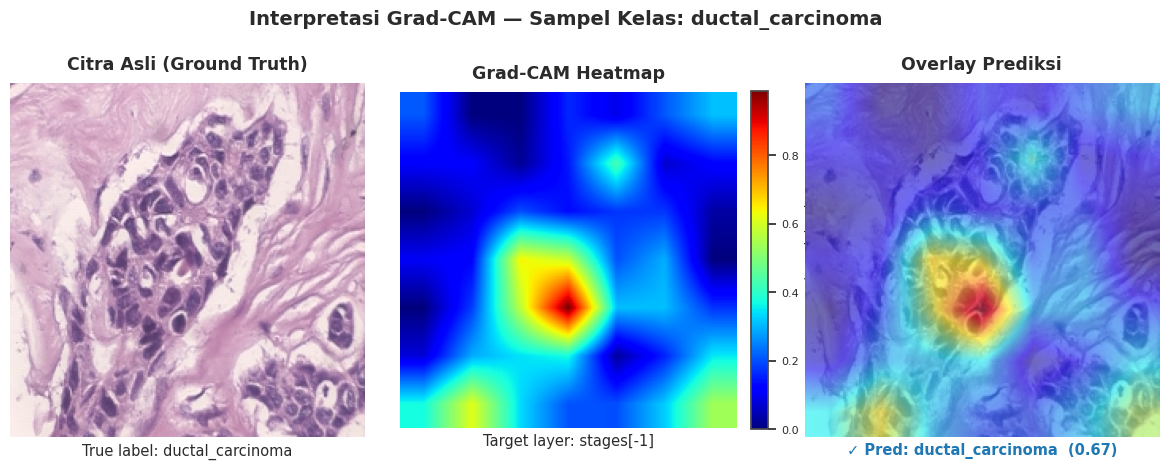

  > Memproses sampel kelas 'tubular_adenoma' (index 349)...


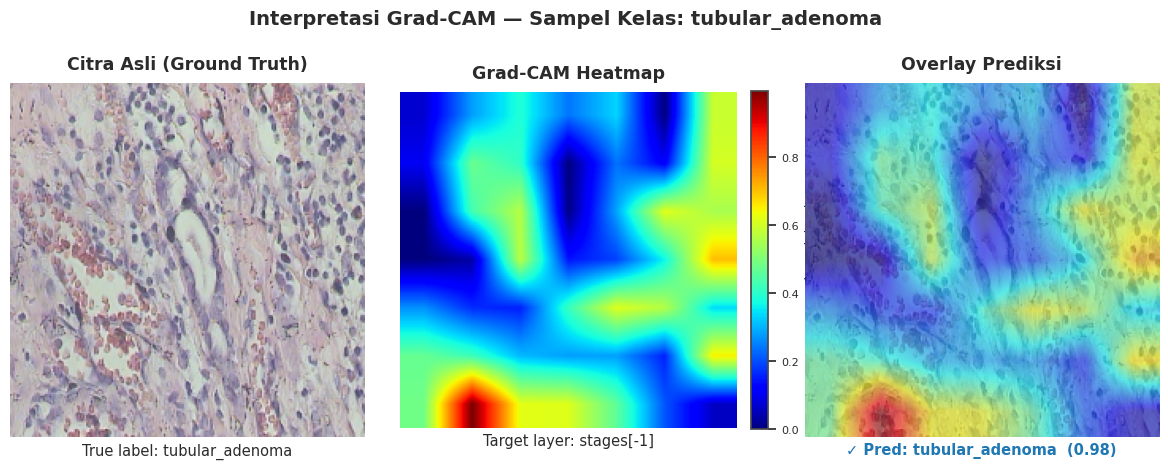

  > Memproses sampel kelas 'ductal_carcinoma' (index 1538)...


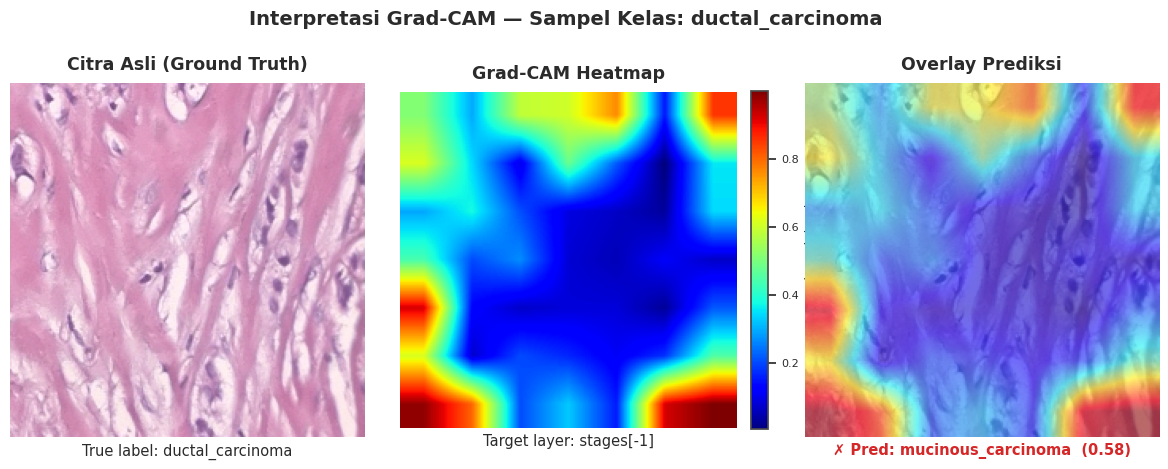


Seluruh visualisasi Grad-CAM tersimpan di: /kaggle/working/laporan_evaluasi


In [11]:
# ==========================================================================
# 10. EXPLAINABLE AI — GRADIENT-WEIGHTED CLASS ACTIVATION MAPPING (GRAD-CAM)
# ==========================================================================
# Grad-CAM (Selvaraju et al., 2017) digunakan untuk menginterpretasikan
# keputusan model dengan memvisualisasikan region citra yang paling
# berkontribusi terhadap prediksi kelas tertentu. Implementasi berikut
# menempatkan hook langsung pada keluaran `backbone.stages[-1]` EdgeNeXt-XXS,
# yaitu peta fitur spasial terakhir (B, 168, 7, 7) sebelum global average
# pooling -- padanan struktural dari blok konvolusi terakhir yang menjadi
# target Grad-CAM pada notebook DenseNet-121. Berbeda dengan DenseNet-121,
# EdgeNeXt-XXS tidak memerlukan modul pembungkus ReLU tambahan karena
# `stages[-1]` sudah merupakan submodul eksplisit yang dapat langsung
# menjadi target hook forward/backward PyTorch.
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib import gridspec

IMAGENET_MEAN_ARR = np.array([0.485, 0.456, 0.406])
IMAGENET_STD_ARR  = np.array([0.229, 0.224, 0.225])

# Palet visual (ACCENT_BLUE, ACCENT_ORANGE, TEXT_DARK) mengacu pada konstanta
# global yang telah didefinisikan pada Bagian 1, sehingga tampilan visual
# tetap selaras dengan grafik evaluasi pada bagian-bagian sebelumnya.


def get_img_array(img_path, size=(224, 224)):
    '''Memuat dan melakukan praproses citra agar sesuai dengan format input
    EdgeNeXt-XXS (normalisasi mean/std ImageNet). Praproses ini HARUS identik
    dengan pipeline pada tahap pelatihan agar interpretasi Grad-CAM konsisten
    dengan representasi yang benar-benar dipelajari model.

    Parameters
    ----------
    img_path : str atau Path
        Lokasi berkas citra sumber.
    size : tuple of int
        Dimensi target (lebar, tinggi) untuk resize citra.

    Returns
    -------
    img_tensor : torch.Tensor
        Tensor citra ternormalisasi berbentuk (1, 3, H, W), siap menjadi
        input model.
    original_img : np.ndarray
        Citra asli dalam rentang [0, 255] (RGB), disimpan untuk keperluan
        visualisasi overlay.
    '''
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    original_img = img.copy()

    img_norm = img.astype(np.float32) / 255.0
    img_norm = (img_norm - IMAGENET_MEAN_ARR) / IMAGENET_STD_ARR
    img_tensor = torch.tensor(img_norm, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)
    return img_tensor, original_img


# Variabel penampung aktivasi & gradien dari peta fitur target (diisi oleh hook)
_activations = {}
_gradients = {}


def _forward_hook(module, input, output):
    _activations['value'] = output


def _backward_hook(module, grad_input, grad_output):
    _gradients['value'] = grad_output[0]


def make_gradcam_heatmap(img_array, model, last_conv_layer_name="stages[-1]"):
    '''Menghasilkan peta panas (heatmap) Grad-CAM berdasarkan gradien kelas
    dengan probabilitas tertinggi terhadap peta aktivasi spasial terakhir
    dari backbone EdgeNeXt-XXS.

    Parameters
    ----------
    img_array : torch.Tensor
        Tensor citra ternormalisasi berbentuk (1, 3, H, W).
    model : nn.Module
        Model EdgeNeXtXXSClassifier yang telah dilatih.
    last_conv_layer_name : str
        Parameter ini BERSIFAT INFORMATIF SAJA dan tidak memengaruhi target
        hook secara aktual -- hook selalu dipasang pada
        `model.backbone.stages[-1]`, yaitu stage konvolusi/attention terakhir
        EdgeNeXt-XXS yang menghasilkan peta fitur spasial (B, 168, 7, 7)
        sebelum global average pooling.

    Returns
    -------
    np.ndarray
        Peta panas dua dimensi ternormalisasi ke rentang [0, 1].
    '''
    img_array = img_array.to(DEVICE)
    model.eval()

    # 1. Pasang hook pada keluaran stage konvolusi terakhir backbone
    target_layer = model.backbone.stages[-1]
    fwd_handle = target_layer.register_forward_hook(_forward_hook)
    bwd_handle = target_layer.register_full_backward_hook(_backward_hook)

    # 2. Forward pass & hitung gradien terhadap kelas berprobabilitas tertinggi
    outputs = model(img_array)
    pred_index = torch.argmax(outputs[0])
    class_channel = outputs[:, pred_index]

    model.zero_grad()
    class_channel.backward()

    # 3. Ambil aktivasi & gradien yang tertangkap oleh hook
    activations = _activations['value'].detach()
    grads = _gradients['value'].detach()

    # 4. Global Average Pooling terhadap gradien -> bobot kepentingan tiap kanal
    pooled_grads = torch.mean(grads, dim=(0, 2, 3))

    # 5. Kombinasi linear terbobot antara peta fitur dan bobot gradiennya
    for i in range(activations.shape[1]):
        activations[:, i, :, :] *= pooled_grads[i]

    heatmap = torch.mean(activations, dim=1).squeeze()

    # 6. ReLU (menahan hanya kontribusi positif terhadap kelas target)
    #    dan normalisasi min-max ke rentang [0, 1]
    heatmap = torch.relu(heatmap) / (torch.max(heatmap) + 1e-8)

    fwd_handle.remove()
    bwd_handle.remove()

    return heatmap.cpu().numpy()


def show_gradcam_multiclass(img_path, true_label_name, model, layer_name="stages[-1]", save_name=None):
    '''Menyusun visualisasi tiga panel: citra asli, heatmap Grad-CAM, dan
    hasil overlay prediksi, dengan tata letak yang konsisten terhadap
    estetika grafik evaluasi pada bagian-bagian sebelumnya notebook ini.

    Parameters
    ----------
    img_path : str
        Lokasi berkas citra uji.
    true_label_name : str
        Label kelas sebenarnya (ground truth) dari citra.
    model : nn.Module
        Model terlatih yang akan dievaluasi.
    layer_name : str
        Nama informatif target Grad-CAM (lihat `make_gradcam_heatmap`).
    save_name : str, optional
        Nama berkas untuk menyimpan hasil visualisasi ke `REPORT_DIR`.
    '''
    # --- Praproses & Prediksi ---
    img_array, original_img = get_img_array(img_path)

    model.eval()
    with torch.no_grad():
        preds = model(img_array.to(DEVICE))
        preds = torch.softmax(preds, dim=1)
    preds_np = preds.cpu().numpy()
    pred_idx = np.argmax(preds_np[0])
    pred_prob = preds_np[0][pred_idx]
    pred_label_name = CLASS_NAMES[pred_idx]
    is_correct = (pred_label_name == true_label_name)

    # --- Pembentukan Heatmap ---
    heatmap = make_gradcam_heatmap(img_array, model, layer_name)
    heatmap_resized = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))

    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    jet_heatmap = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    jet_heatmap = cv2.cvtColor(jet_heatmap, cv2.COLOR_BGR2RGB)

    ALPHA = 0.55
    superimposed_img = cv2.addWeighted(jet_heatmap, ALPHA, original_img, 1 - ALPHA, 0)

    # --- Tata Letak Visualisasi ---
    fig = plt.figure(figsize=(15, 4.6))
    gs = gridspec.GridSpec(1, 3, wspace=0.08)
    fig.patch.set_facecolor('white')

    panel_titles = ['Citra Asli (Ground Truth)', 'Grad-CAM Heatmap', 'Overlay Prediksi']
    panel_data = [original_img, None, superimposed_img]

    ax0 = fig.add_subplot(gs[0])
    ax0.imshow(original_img)
    ax0.set_title(panel_titles[0], fontsize=12.5, fontweight='bold', color=TEXT_DARK, pad=10)
    ax0.set_xlabel(f'True label: {true_label_name}', fontsize=10.5, color=TEXT_DARK)
    ax0.set_xticks([]); ax0.set_yticks([])
    for spine in ax0.spines.values():
        spine.set_visible(False)

    ax1 = fig.add_subplot(gs[1])
    im = ax1.imshow(heatmap_resized, cmap='jet')
    ax1.set_title(panel_titles[1], fontsize=12.5, fontweight='bold', color=TEXT_DARK, pad=10)
    ax1.set_xlabel(f'Target layer: {layer_name}', fontsize=10.5, color=TEXT_DARK)
    ax1.set_xticks([]); ax1.set_yticks([])
    for spine in ax1.spines.values():
        spine.set_visible(False)
    cbar = fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
    cbar.set_label('Intensitas Aktivasi', fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    ax2 = fig.add_subplot(gs[2])
    ax2.imshow(superimposed_img)
    status_color = ACCENT_BLUE if is_correct else '#d62728'
    status_mark = '✓' if is_correct else '✗'
    ax2.set_title(panel_titles[2], fontsize=12.5, fontweight='bold', color=TEXT_DARK, pad=10)
    ax2.set_xlabel(f'{status_mark} Pred: {pred_label_name}  ({pred_prob:.2f})',
                    fontsize=10.5, fontweight='bold', color=status_color)
    ax2.set_xticks([]); ax2.set_yticks([])
    for spine in ax2.spines.values():
        spine.set_visible(False)

    fig.suptitle(f'Interpretasi Grad-CAM — Sampel Kelas: {true_label_name}',
                 fontsize=14, fontweight='bold', color=TEXT_DARK, y=1.04)

    plt.tight_layout()
    if save_name:
        plt.savefig(os.path.join(REPORT_DIR, save_name), dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()


# ==========================================================================
# Eksekusi Grad-CAM pada Sampel Data Uji
# ==========================================================================
print("Menghasilkan visualisasi Grad-CAM untuk sampel data uji...")

N_SAMPLES = 3
sample_test = test_df.sample(N_SAMPLES, random_state=42)

for index, row in sample_test.iterrows():
    print(f"  > Memproses sampel kelas '{row['label']}' (index {index})...")
    show_gradcam_multiclass(
        img_path=row['filepath'],
        true_label_name=row['label'],
        model=model,
        layer_name="stages[-1]",
        save_name=f"05_gradcam_{index}_{row['label']}.png"
    )

print(f"\nSeluruh visualisasi Grad-CAM tersimpan di: {REPORT_DIR}")


## 11. Download Semua Laporan Evaluasi

Sel di bawah ini mengumpulkan seluruh artefak evaluasi yang telah disimpan sepanjang notebook (ilustrasi augmentasi, kurva akurasi/loss, classification report, confusion matrix, kurva ROC/PR, dan Grad-CAM) menjadi satu berkas `.zip`, kemudian menampilkan tautan unduhan.

> Jalankan sel ini **setelah** seluruh sel evaluasi di atas selesai dieksekusi.

In [12]:
# ==============================================================================
# 11. UNDUH SELURUH LAPORAN EVALUASI
# ==============================================================================
# Seluruh artefak evaluasi yang tersimpan sepanjang notebook (ilustrasi
# augmentasi, kurva akurasi/loss, classification report, confusion matrix,
# kurva ROC/PR, dan visualisasi Grad-CAM) dikompresi menjadi satu berkas
# arsip (.zip) untuk memudahkan pengunduhan dan dokumentasi pada laporan
# skripsi.
import shutil
from IPython.display import FileLink, display

ZIP_BASENAME = f'/kaggle/working/laporan_evaluasi_edgenext_xxs_{TARGET_MAGNIFICATION}'
zip_path = shutil.make_archive(ZIP_BASENAME, 'zip', REPORT_DIR)

print('Berkas laporan yang berhasil disimpan:')
for fname in sorted(os.listdir(REPORT_DIR)):
    print(f'  - {fname}')

print(f'\nBerkas ZIP berhasil dibuat: {zip_path}')
print('Klik tautan berikut untuk mengunduh, atau buka panel "Output" pada sisi kanan notebook Kaggle.')

display(FileLink(zip_path))


Berkas laporan yang berhasil disimpan:
  - 00_ilustrasi_augmentasi_200X.png
  - 01_grafik_akurasi_loss_200X.png
  - 02_classification_report_200X.csv
  - 02_classification_report_200X.txt
  - 03_confusion_matrix_200X.csv
  - 03_confusion_matrix_200X.png
  - 04_roc_pr_curve_200X.png
  - 05_gradcam_1538_ductal_carcinoma.png
  - 05_gradcam_1796_ductal_carcinoma.png
  - 05_gradcam_349_tubular_adenoma.png

Berkas ZIP berhasil dibuat: /kaggle/working/laporan_evaluasi_edgenext_xxs_200X.zip
Klik tautan berikut untuk mengunduh, atau buka panel "Output" pada sisi kanan notebook Kaggle.


/kaggle/working/laporan_evaluasi_edgenext_xxs_200X.zip